## Análisis de Inteligencia de Negocios: Transacciones Retail en Istanbul (2021–2023)

<h4>Objetivo:</h4> Analizar el comportamiento de compra, la composición demográfica y las tendencias de ingresos para identificar oportunidades estratégicas de crecimiento y optimización comercial.

In [290]:
# Importamos las liberías
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as py

In [291]:
# Leémos nuestro dataset
data = pd.read_csv('customer_shopping_data.csv')

##### Comprensión de los Datos

In [292]:
# Vemos la información general del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [293]:
# Vemos un resumen de forma general de los datos númericos del dataset
data.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [294]:
data.sample(10)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
90742,I255083,C771006,Male,31,Food & Beverage,4,20.92,Debit Card,8/5/2022,Istinye Park
96987,I272542,C534236,Female,68,Food & Beverage,2,10.46,Credit Card,1/6/2021,Metropol AVM
20955,I308412,C818077,Male,36,Toys,2,71.68,Credit Card,5/8/2022,Mall of Istanbul
52341,I301172,C171366,Male,68,Clothing,4,1200.32,Cash,22/04/2022,Kanyon
57412,I212206,C537585,Male,62,Clothing,1,300.08,Debit Card,2/10/2021,Cevahir AVM
65669,I449267,C485476,Female,37,Clothing,3,900.24,Cash,22/04/2021,Metrocity
39406,I228995,C181850,Male,44,Cosmetics,2,81.32,Cash,21/02/2022,Mall of Istanbul
15846,I329440,C283160,Male,58,Cosmetics,4,162.64,Credit Card,29/08/2021,Kanyon
76365,I597971,C256230,Male,23,Clothing,1,300.08,Credit Card,9/11/2022,Emaar Square Mall
54741,I190257,C959222,Male,20,Clothing,4,1200.32,Cash,29/11/2022,Mall of Istanbul


<b>Observaciones:</b> Podemos observar que contamos con todos los datos necesarios para realizar el análisis, se realizó una impresión aleatoria del dataset para comprender el tipo de datos que contenemos, así como con describe pudimos obtener un panorama general de los datos númericos que contenemos en el registro. 

##### Preparación de Datos

In [295]:
# Revisamos los valores vacíos
data.isna().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [296]:
# Revisamos si tenemos datos duplicados
duplicates = data.duplicated().sum()
print('Valores duplicados: ', duplicates)

Valores duplicados:  0


In [ ]:
# Corregimos el tipo de dato del dataset
data['invoice_date'] = pd.to_datetime(data['invoice_date'], format='%d/%m/%Y')

In [298]:
# Obtenemos el valor promedio de una venta
print(f'Ventas promedio: {data['price'].mean()}')

Ventas promedio: 689.2563209226097


Analizamos con un cuadro de caja si contamos un valores atípicos


<Axes: ylabel='price'>

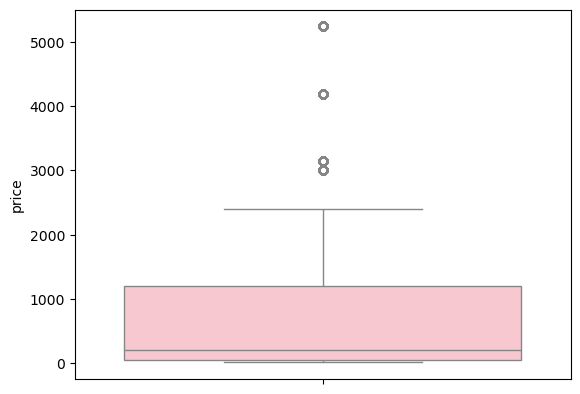

In [299]:
# Diagrama de caja general de las ventas
print("Analizamos con un cuadro de caja si contamos un valores atípicos")
sns.boxplot(data['price'], color='pink')

In [ ]:
# vamos a calcular la moda
print("Al contar con valores atípicos, calculamos la moda ya que es una metríca más segura:")
print(f"Moda de las ventas generadas: {data['price'].mode()[0]}")

Al contar con valores atípicos, calculamos la moda ya que es una metríca más segura:
Moda de las ventas generadas: 600.16


In [ ]:
# Vamos a obtener el total de ventas generadas
print(f"Total de ventas generadas: ${data['price'].sum():.2f}")

Total de ventas generadas: $68551365.91


<b>Observaciones:</b> 

Con base en la fase de comprensión de los datos, se decidió ajustar el tipo de dato del campo invoice_date a formato fecha, con el objetivo de facilitar su uso en análisis temporales posteriores.

Asimismo, se verificó la calidad del dataset confirmando la ausencia de valores nulos y registros duplicados que pudieran generar sesgos o ruido en el análisis.

Inicialmente se contempló la creación de una nueva variable denominada revenue. Sin embargo, tras revisar la documentación y aclaraciones del dataset en Kaggle, se confirmó que la variable price ya representa el valor total por transacción (Quantity * Unit Price), y no el precio unitario.
Por lo tanto, se decidió trabajar directamente con esta variable como indicador de ingresos.

Como parte del análisis exploratorio inicial, se calcularon métricas generales de enriquecimiento:

Promedio de ventas por transacción: $689.25

Moda: $600.16 (considerando la presencia de valores atípicos)

Total de ventas generadas en el período: $68,551,365.91

#### Desarrollo de KPIs

##### Ventas por Categoría

In [302]:
# Vamos a agrupar por cateogoría para ver el comportamiento de las ventas.
categorias = data.groupby('category').agg(ventas=('price', 'sum'),
                                          promedio=('price', 'mean')).reset_index().sort_values(by='ventas', ascending=False)
categorias['porcentaje'] = round(
    (categorias['ventas']/data['price'].sum())*100, 2)
categorias

,category,ventas,promedio,porcentaje
1,Clothing,31075684.64,901.084021,45.33
4,Shoes,18135336.89,1807.388568,26.46
6,Technology,15772050.00,3156.935548,23.01
2,Cosmetics,1848606.90,122.448626,2.70
7,Toys,1086704.64,107.733185,1.59
3,Food & Beverage,231568.71,15.671948,0.34
0,Books,226977.30,45.568621,0.33
5,Souvenir,174436.83,34.894345,0.25


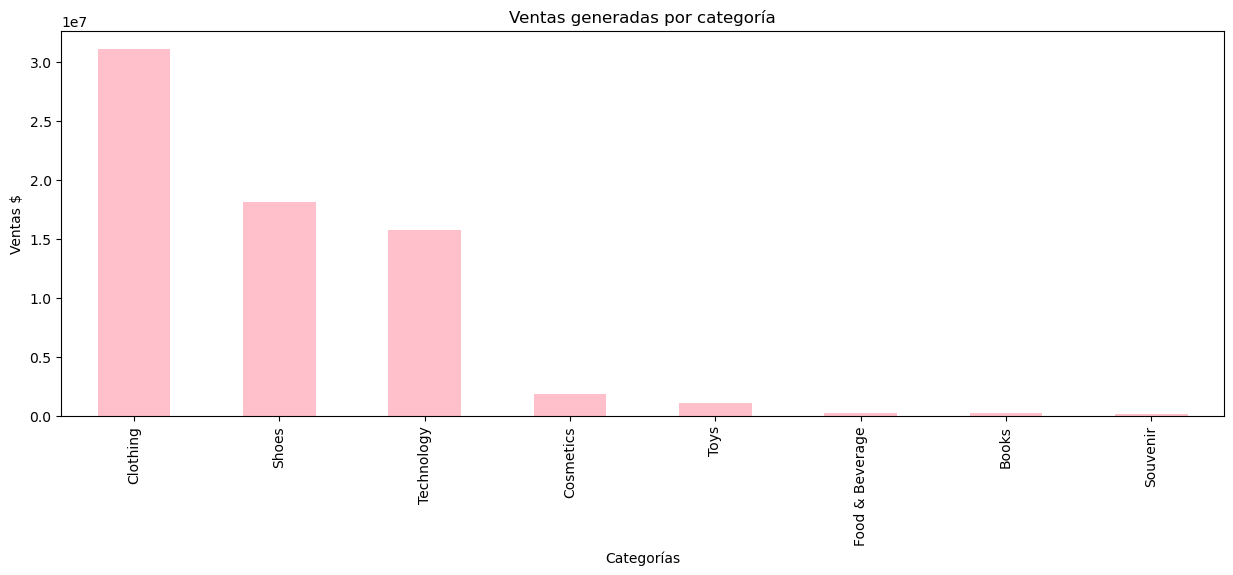

In [303]:
# Visualizamos los datos obtenidos
categorias.plot(kind='bar',
                x='category',
                y='ventas',
                color='pink',
                title='Ventas generadas por categoría',
                legend=False,
                figsize=[15, 5],
                xlabel='Categorías',
                ylabel='Ventas $'
                )
plt.show()

<b>Observaciones:</b><br><br>
Se agruparon los datos por categoría de producto con el objetivo de analizar el comportamiento de las ventas, calculando las ventas totales, el promedio y su porcentaje respecto a las ventas globales.

Los resultados muestran que la categoría Clothing domina ampliamente las ventas, representando el 45.33% del total, lo que significa que casi la mitad de las ventas generadas provienen de esta categoría.

En segundo lugar se encuentra la categoría Shoes, con un 26.46%, mostrando una diferencia considerable respecto a la categoría líder.

Este resultado sugiere que la ropa es el principal motor de ingresos dentro de los centros comerciales analizados, lo que podría indicar una mayor demanda o una mayor diversidad de productos dentro de esta categoría.

##### Ventas por género

In [304]:
# Vamos a agrupar por género para ver el comportamiento de las ventas.
genero = data.groupby('gender').agg(ventas=('price', 'sum'),
                                    promedio=('price', 'mean')).reset_index().sort_values(by='ventas', ascending=False)
genero['porcentaje'] = round((genero['ventas']/data['price'].sum())*100, 2)
genero

,gender,ventas,promedio,porcentaje
0,Female,40931801.62,688.137615,59.71
1,Male,27619564.29,690.920933,40.29


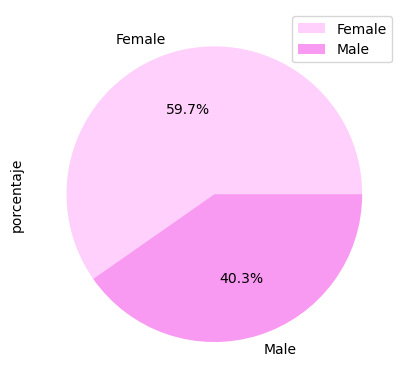

In [305]:
# Visualiamos el resultado
genero.plot(kind='pie', y='porcentaje', labels=genero['gender'], autopct='%1.1f%%', colors=[
            "#FFB6FAA4", "#F55CEB9E", "#F812E9C3"])
plt.show()

<b>Observaciones:</b><br><br>
Con base en el análisis anterior, se decidió explorar el comportamiento de compra según el género de los clientes.

Los resultados muestran que los compradores femeninos generan el 59.71% de las ventas, lo que indica una mayor participación en el consumo dentro de los centros comerciales analizados.

Este comportamiento puede estar relacionado con la fuerte presencia de la categoría Clothing, que es la que concentra la mayor proporción de ventas.

##### Ventas por rango de edad

In [306]:
# Vamos a crear un rango de edad para aagrupar de esta forma y analizar su comportamiento
bins = [18, 24, 34, 44, 54, 64, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=True)

edad = data.groupby('age_group').agg(ventas=('price', 'sum'),
                                     promedio=('price', 'mean')).reset_index().sort_values(by='ventas', ascending=False)
edad['porcentaje'] = round((edad['ventas']/data['price'].sum())*100, 2)
edad

/var/folders/z8/z7ff3tyd5872vxcp6341_nzw0000gn/T/ipykernel_56529/914212508.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edad = data.groupby('age_group').agg(ventas=('price', 'sum'),


,age_group,ventas,promedio,porcentaje
2,35-44,13584504.96,700.196122,19.82
3,45-54,13206068.93,693.268357,19.26
1,25-34,13089584.64,686.000977,19.09
4,55-64,13010651.30,684.663016,18.98
0,18-24,7949246.07,682.221599,11.60
5,65+,6499846.39,689.492563,9.48


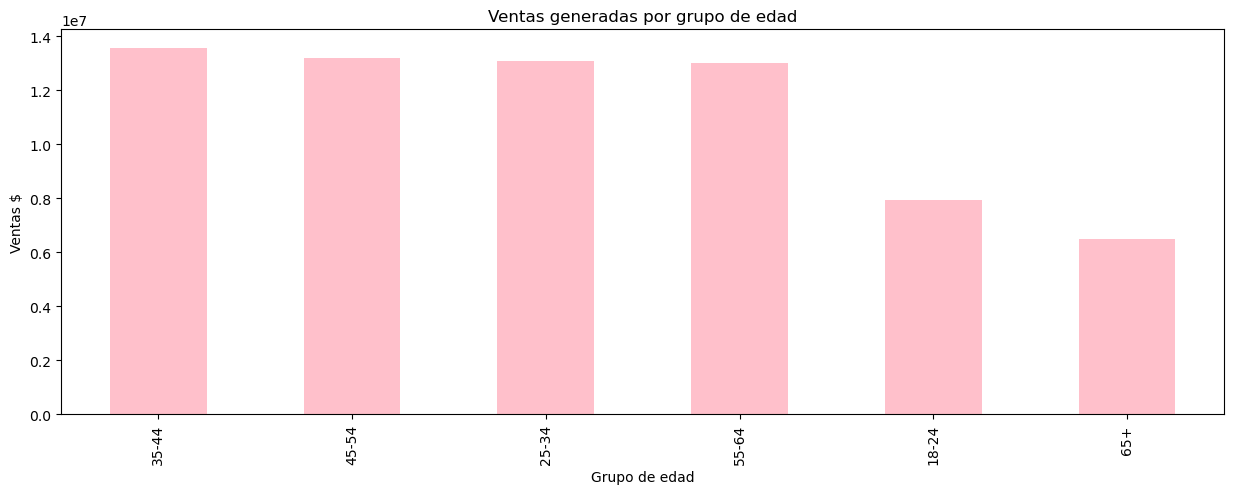

In [307]:
# Visualizamos los datos obtenidos
edad.plot(kind='bar',
          x='age_group',
          y='ventas',
          color='pink',
          title='Ventas generadas por grupo de edad',
          legend=False,
                figsize=[15, 5],
          xlabel='Grupo de edad',
          ylabel='Ventas $'
          )
plt.show()

<b>Observaciones:</b><br><br>
Para comprender mejor el perfil de los compradores, se creó una nueva variable que agrupa a los clientes en rangos de edad, con el objetivo de analizar qué segmentos generan mayor volumen de ventas.

El análisis muestra que el grupo de 35 a 44 años concentra el mayor porcentaje de ventas con 19.82%.

Sin embargo, la diferencia con otros grupos es relativamente pequeña.
Los rangos 45 a 54 años (19.26%) y 25 a 34 años (19.09%) presentan participaciones muy similares.

Esto sugiere que el consumo está distribuido de forma bastante equilibrada entre los segmentos de edad adultos, mientras que los grupos 18 a 24 años y mayores de 65 años presentan una participación menor, ambos por debajo del 15%.

##### Preferencia de pago

In [308]:
metodo_pago = data.groupby('payment_method').agg(ventas=('price', 'sum'),
                                                 promedio=('price', 'mean'),
                                                 cantidad=('payment_method', 'count')).reset_index().sort_values(by='cantidad', ascending=False)
metodo_pago['porcentaje'] = round(
    (metodo_pago['ventas']/data['price'].sum())*100, 2)
metodo_pago

,payment_method,ventas,promedio,cantidad,porcentaje
0,Cash,30705030.98,690.823475,44447,44.79
1,Credit Card,24051476.93,688.542467,34931,35.09
2,Debit Card,13794858.00,687.029135,20079,20.12


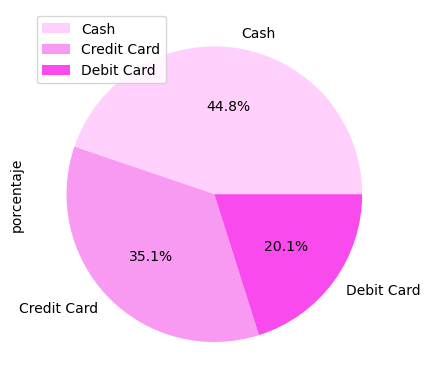

In [309]:
# Visualiamos el resultado
metodo_pago.plot(kind='pie', y='porcentaje', labels=metodo_pago['payment_method'], autopct='%1.1f%%', colors=[
                 "#FFB6FAA4", "#F55CEB9E", "#F812E9C3"])
plt.show()

<b>Observaciones:</b><br><br>
Se analizó el método de pago utilizado por los compradores para identificar posibles preferencias en las transacciones.

El efectivo aparece como el método de pago predominante con 44.8% de las transacciones, seguido por tarjeta de crédito (35.1%) y tarjeta de débito (20.1%).

Sin embargo, este resultado debe interpretarse con cautela, ya que podría no reflejar únicamente una preferencia del consumidor. También podría estar influenciado por limitaciones en los métodos de pago aceptados en algunos establecimientos dentro de los centros comerciales.

Por ello, sería recomendable contar con información adicional sobre las políticas de pago de cada tienda, para determinar si esta tendencia responde a una preferencia del cliente o a restricciones operativas.

##### Ventas por periodo de fechas

In [360]:
data['year'] = data['invoice_date'].dt.isocalendar().year
data['month'] = data['invoice_date'].dt.month
data['period'] = data['invoice_date'].dt.to_period('M')
data['trimestre'] = data['invoice_date'].dt.to_period('Q')
top_month = data.groupby(['period']).agg(ventas=('price', 'sum'),
                                        promedio=('price', 'mean')).sort_values(by='ventas',ascending=False).reset_index()
top_month['porcentaje'] = round((top_month['ventas']/data['price'].sum())*100, 2)
print("Periodos con mayores ventas generadas")
top_month

Periodos con mayores ventas generadas


,period,ventas,promedio,porcentaje
0,2021-07,2802468.58,703.430868,4.09
1,2021-10,2782418.40,710.525638,4.06
2,2022-10,2755839.69,716.174556,4.02
3,2022-07,2749554.99,706.281785,4.01
4,2022-03,2705190.76,685.378961,3.95
5,2022-05,2684556.89,697.468665,3.92
6,2022-12,2675437.80,704.247907,3.90
7,2021-05,2662369.93,691.884077,3.88
8,2021-01,2656422.78,692.678691,3.88
9,2022-01,2656149.96,690.447091,3.87


In [370]:
print(f"Ventas promedio:{top_month['porcentaje'].mean():.2}%")
print(f"Ventas - mediana:{top_month['porcentaje'].median():.2}%")

Ventas promedio:3.7%
Ventas - mediana:3.8%


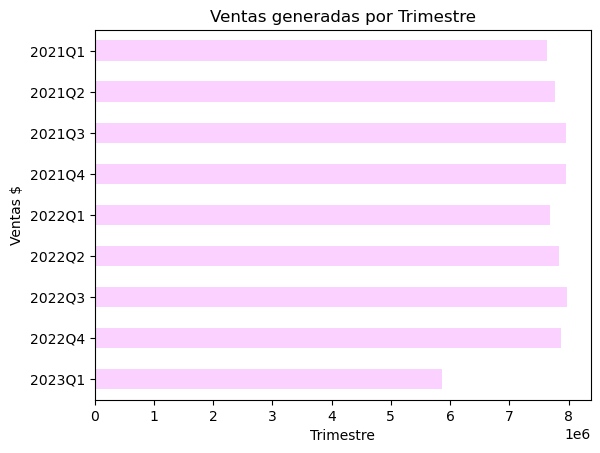

In [363]:
fechas_consecutivo = data.groupby(['trimestre']).agg(ventas=('price', 'sum'))\
                            .sort_values(by='trimestre',ascending=False).reset_index()

# Visualizamos los datos obtenidos
fechas_consecutivo.plot(kind='barh',
                      x='trimestre',
                      y='ventas',
                      color="#fbd1ff", 
                      title='Ventas generadas por Trimestre',
                      legend=False,
                      #figsize=[15, 5],
                      xlabel='Trimestre',
                      ylabel='Ventas $'
                      )
plt.show()

<b>Observaciones:</b><br><br>
Se analizaron las ventas agrupadas por periodo de tiempo para identificar posibles patrones o variaciones significativas en el comportamiento de compra.

Los resultados muestran que las ventas se mantienen relativamente estables entre los distintos periodos, sin diferencias marcadas entre los meses o trimestres analizados.

Adicionalmente, se calcularon medidas como la moda y la mediana, las cuales presentan valores cercanos al promedio general, lo que confirma que no existen fluctuaciones drásticas en las ventas durante el periodo analizado.

También se identificó que el último periodo presenta valores menores, posiblemente debido a que corresponde a un periodo incompleto dentro del dataset, por lo que no se considera representativo para el análisis.

##### Ventas por centro comercial

In [310]:
# Agrupamos los datos por centro comercial.
centro_comercial = data.groupby('shopping_mall').agg(ventas=('price', 'sum'),
                                                     promedio=('price', 'mean')).sort_values(by='ventas', ascending=False).reset_index()
centro_comercial['porcentaje'] = round(
    (centro_comercial['ventas']/data['price'].sum())*100, 2)
centro_comercial

,shopping_mall,ventas,promedio,porcentaje
0,Mall of Istanbul,13851737.62,694.566395,20.21
1,Kanyon,13710755.24,691.658944,20.00
2,Metrocity,10249980.07,682.831262,14.95
3,Metropol AVM,6937992.99,682.806120,10.12
4,Istinye Park,6717077.54,686.747525,9.80
5,Zorlu Center,3509649.02,691.556457,5.12
6,Cevahir AVM,3433671.84,687.972719,5.01
7,Viaport Outlet,3414019.46,694.753655,4.98
8,Emaar Square Mall,3390408.31,704.720081,4.95
9,Forum Istanbul,3336073.82,674.363012,4.87


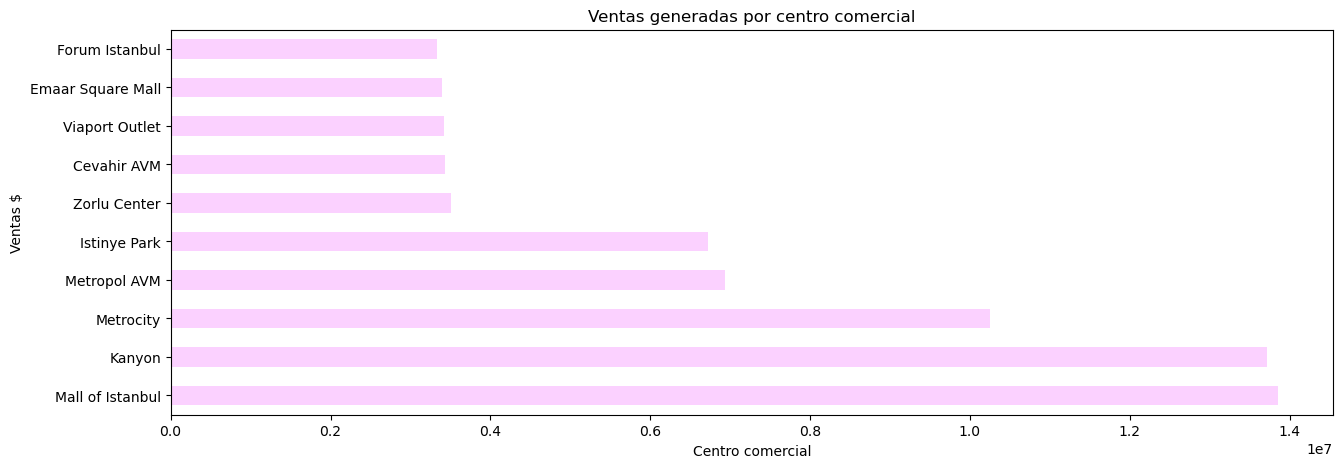

In [371]:
# Visualizamos los datos obtenidos
centro_comercial.plot(kind='barh',
                      x='shopping_mall',
                      y='ventas',
                      color="#fbd1ff", 
                      title='Ventas generadas por centro comercial',
                      legend=False,
                      figsize=[15, 5],
                      xlabel='Centro comercial',
                      ylabel='Ventas $'
                      )
plt.show()

<b>Observaciones:</b><br><br>
Se analizaron las ventas totales generadas por cada centro comercial con el objetivo de identificar las ubicaciones con mayor desempeño.

Los resultados muestran que Mall of Istanbul y Kanyon destacan como los centros comerciales con mayor volumen de ventas, representando aproximadamente el 20% cada uno del total.

En conjunto, ambos centros comerciales generan alrededor del 40% de las ventas totales, lo que los posiciona como los principales puntos de consumo dentro del dataset.

En tercer lugar se encuentra Metrocity, con aproximadamente 15% de participación, marcando una diferencia considerable respecto a los dos centros líderes.

##### Ventas por categorías y centro comercial

In [330]:
# Agrupamos los datos por centro comercial.
centro_comercial_c = data.groupby(['shopping_mall', 'category']).agg(ventas=('price', 'sum'),
                                                                     promedio=('price', 'mean')).sort_values(by='ventas', ascending=False).reset_index()
centro_comercial_c['porcentaje'] = round(
    (centro_comercial_c['ventas']/data['price'].sum())*100, 2)
print("TOP 10 ventas (Centro comercial/Categoría)")
centro_comercial_c.head(10)

TOP 10 ventas (Centro comercial/Categoría)


,shopping_mall,category,ventas,promedio,porcentaje
0,Mall of Istanbul,Clothing,6245565.04,902.147196,9.11
1,Kanyon,Clothing,6155541.04,899.932901,8.98
2,Metrocity,Clothing,4719958.32,895.967790,6.89
3,Mall of Istanbul,Shoes,3668239.04,1813.266950,5.35
4,Kanyon,Shoes,3640031.05,1804.675781,5.31
5,Mall of Istanbul,Technology,3220350.00,3166.519174,4.70
6,Kanyon,Technology,3202500.00,3212.136409,4.67
7,Metropol AVM,Clothing,3166444.16,898.282031,4.62
8,Istinye Park,Clothing,3050313.20,909.726573,4.45
9,Metrocity,Shoes,2610139.33,1791.447721,3.81


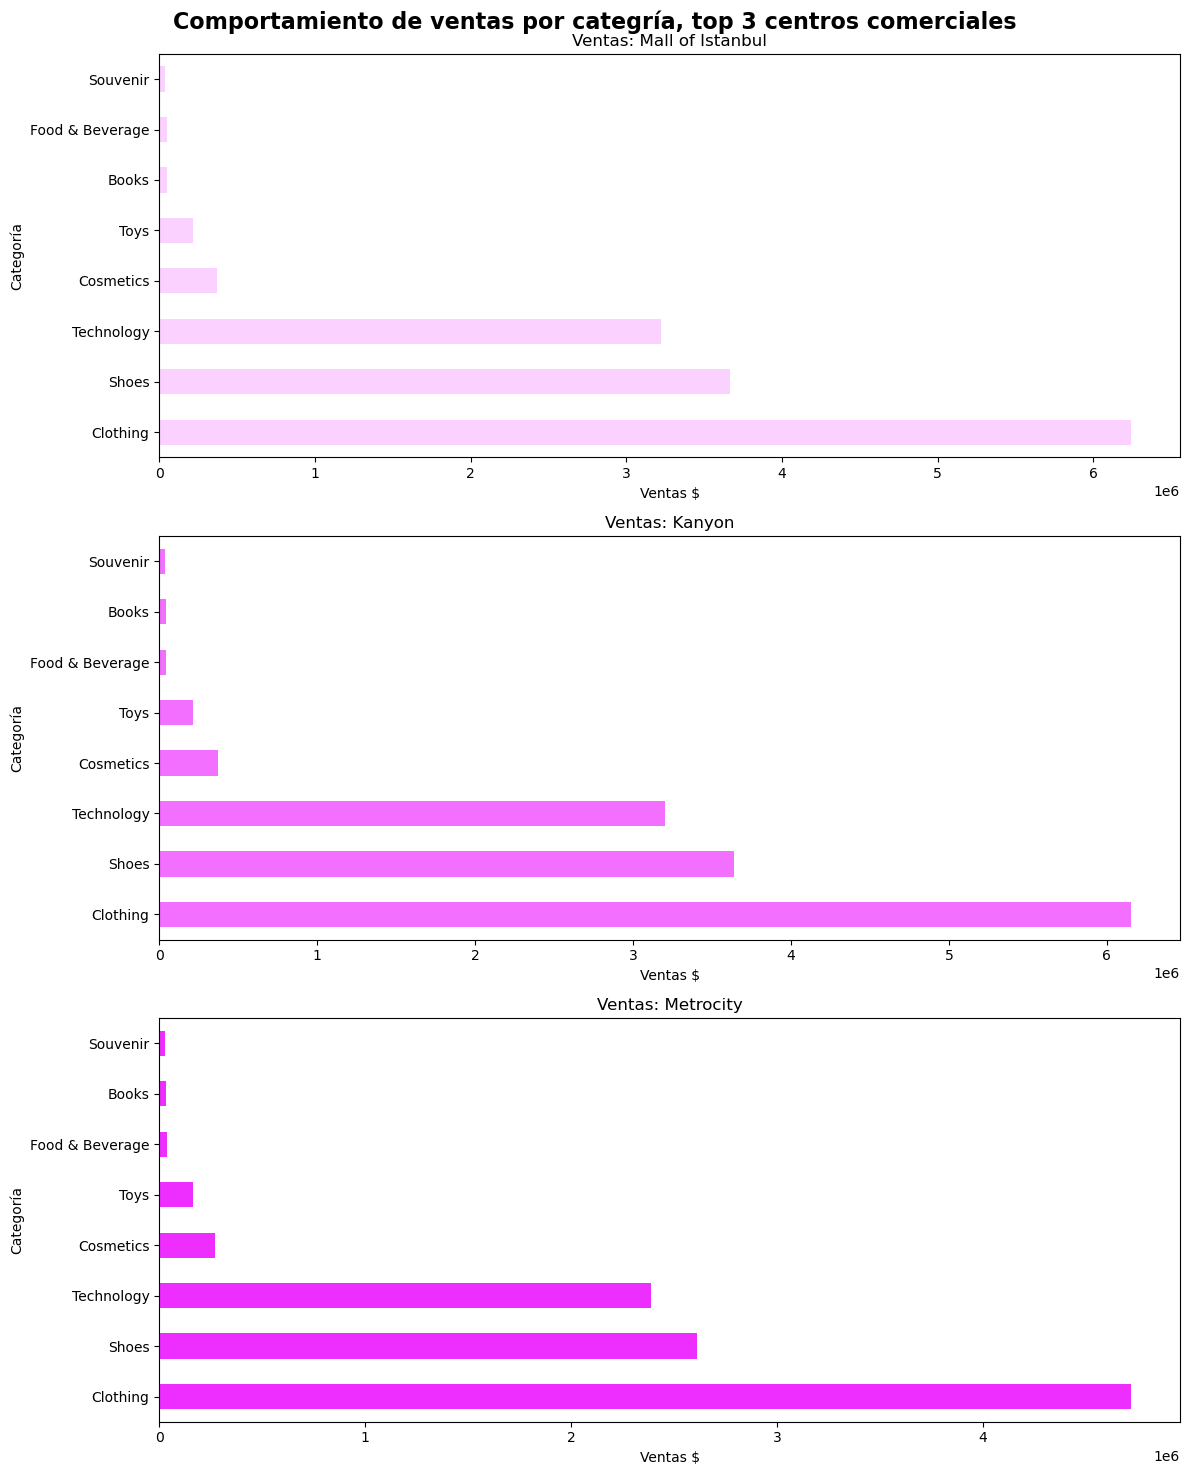

In [334]:
#Visualizamos el comportamiento por categoría de los principales centros comerciales
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15)) 
fig.suptitle('Comportamiento de ventas por categría, top 3 centros comerciales', fontsize=16, fontweight='bold')

c1 = centro_comercial_c[centro_comercial_c['shopping_mall'] == centro_comercial['shopping_mall'][0]]
c1.plot(kind='barh', 
                x ='category', 
                y='ventas', 
                color="#fbd1ff", 
                title=f'Ventas generadas por categoría "{centro_comercial['shopping_mall'][0]}"',
                legend = False,
                xlabel = 'Ventas $',
                ax=axes[0]
               )
axes[0].set_title(f'Ventas: {centro_comercial["shopping_mall"][0]}')
axes[0].set_ylabel('Categoría')

c2 = centro_comercial_c[centro_comercial_c['shopping_mall'] == centro_comercial['shopping_mall'][1]]
c2.plot(kind='barh', 
                x ='category', 
                y='ventas', 
                color="#f36fff", 
                title=f'Ventas generadas por categoría "{centro_comercial['shopping_mall'][1]}"',
                legend = False,
                xlabel = 'Ventas $',
                ax=axes[1]
               )
axes[1].set_title(f'Ventas: {centro_comercial["shopping_mall"][1]}')
axes[1].set_ylabel('Categoría')

c3 = centro_comercial_c[centro_comercial_c['shopping_mall'] == centro_comercial['shopping_mall'][2]]
c3.plot(kind='barh', 
                x ='category', 
                y='ventas', 
                color="#ee2eff", 
                title=f'Ventas generadas por categoría "{centro_comercial['shopping_mall'][2]}"',
                legend = False,
                xlabel = 'Ventas $',
                ax=axes[2]
               )
axes[2].set_title(f'Ventas: {centro_comercial["shopping_mall"][2]}')
axes[2].set_ylabel('Categoría')

plt.tight_layout() # Ajusta automáticamente los espacios para que no se superpongan los títulos
plt.show()

<b>Observaciones:</b><br><br>
Después de identificar los centros comerciales con mayor volumen de ventas, se analizó la distribución de ventas por categoría dentro de cada uno de ellos para identificar posibles diferencias en el comportamiento de compra.

Los resultados muestran que el patrón de consumo es muy similar entre los distintos centros comerciales.

En todos los casos destaca la categoría Clothing, seguida por Shoes y Technology, manteniendo proporciones relativamente consistentes entre las diferentes ubicaciones.

Esto sugiere que las preferencias de los consumidores no varían significativamente entre centros comerciales, lo que podría indicar que la oferta de productos y el perfil de los compradores es similar entre estas ubicaciones.

#### Conclusiones generales:



A partir del análisis realizado sobre las transacciones de compra en distintos centros comerciales de Estambul entre 2021 y 2023, se identificaron varios patrones relevantes en el comportamiento de los consumidores y en la distribución de las ventas.

En primer lugar, la categoría Clothing destaca como el principal generador de ingresos, concentrando casi la mitad de las ventas totales. Esto indica que los productos relacionados con ropa representan el motor principal del consumo dentro de los centros comerciales analizados.

En cuanto al perfil de los compradores, se observa que las mujeres generan una mayor proporción de las ventas, lo cual podría estar relacionado con la fuerte presencia de la categoría de ropa dentro de las transacciones.

Respecto a la distribución por edad, las ventas se encuentran relativamente equilibradas entre los grupos de 25 a 54 años, destacando ligeramente el rango de 35 a 44 años. Esto sugiere que el consumo está concentrado principalmente en la población adulta económicamente activa.

El análisis de métodos de pago muestra que el efectivo continúa siendo el método más utilizado, seguido de las tarjetas de crédito y débito. Sin embargo, este resultado podría estar influenciado por factores externos como las políticas de pago de algunos establecimientos.

Por otro lado, al analizar las ventas a lo largo del tiempo, no se identificaron fluctuaciones estacionales significativas, lo que sugiere que el comportamiento de compra se mantiene relativamente estable durante el periodo analizado.

Finalmente, al evaluar el desempeño por ubicación, se identificó que Mall of Istanbul y Kanyon concentran una parte importante de las ventas totales, lo que los posiciona como los centros comerciales con mayor actividad comercial dentro del dataset.

#### Insights de Negocio

Con base en los resultados obtenidos, se pueden identificar algunos insights relevantes para la toma de decisiones:

La categoría Clothing representa una oportunidad clave para estrategias de marketing, promociones o ampliación de inventario.

Los clientes femeninos representan el principal segmento de consumo dentro del dataset.

El grupo de edad entre 25 y 54 años concentra la mayor actividad de compra.

Los centros comerciales Mall of Istanbul y Kanyon concentran gran parte de la actividad comercial.

El uso predominante de efectivo sugiere posibles oportunidades para promover métodos de pago digitales.